In [1]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model and tokenizer
model_name = "Helsinki-NLP/opus-mt-de-en"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def global_magnitude_prune(model, prune_percent):
    """Global pruning using numpy.percentile for threshold calculation"""
    all_weights = []
    
    with torch.no_grad():
        for name, param in model.named_parameters():
            if 'weight' in name and 'LayerNorm' not in name and 'bias' not in name:
                weights = param.data.abs().cpu().numpy().ravel()
                all_weights.append(weights)
        
        if not all_weights:
            return model
        
        flat_weights = np.concatenate(all_weights)
        threshold = np.percentile(flat_weights, prune_percent)
        
        for name, param in model.named_parameters():
            if 'weight' in name and 'LayerNorm' not in name and 'bias' not in name:
                mask = param.data.abs() > torch.tensor(threshold, device=param.device)
                param.data.mul_(mask)
    
    return model

def translate_sentence(model, sentence):
    model.eval()
    model.to(device)
    inputs = tokenizer(sentence, return_tensors="pt", padding=True, truncation=True).to(device)
    with torch.no_grad():
        outputs = model.generate(**inputs)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Sentence to translate
german_sentence = "wenn ich sie fragen würde , die großen weltreligionen aufzuzählen , was würden sie sagen ?"

# Prune percentages
prune_levels = [30, 50]

# Translate with pruned models
for pct in prune_levels:
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)
    pruned_model = global_magnitude_prune(model, pct)
    translation = translate_sentence(pruned_model, german_sentence)
    print(f"Pruned {pct}%: {translation}")


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.38k [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/797k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/768k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.27M [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/298M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/298M [00:00<?, ?B/s]

Pruned 30%: if I would ask you to list the great world religions, what would you say?
Pruned 50%: If I'd ask you, tell you about the great world , what'd you say, what'd you say, what'd you'd say, what'd you'd say, what'd you say, what'd you say, what'd you say, what'd you'd say, what'd you'd, what'd you'd say, what'd you'd say, what'd you'd say, what'd you'd say, what'd you'd say, what'd you'd, what'd you'd say, what'd you'd, what'd you'd say, what'd you'd know, what'd you'd'd'd'd'd'd'd'd's point, what'd you'd'd'd's point, what'd you'd'd's point, what'd'd'd'd's point, what, what'd'd'd'd'd'd'd'd'd'd's point, what, what'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'd'


/usr/local/lib/python3.11/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


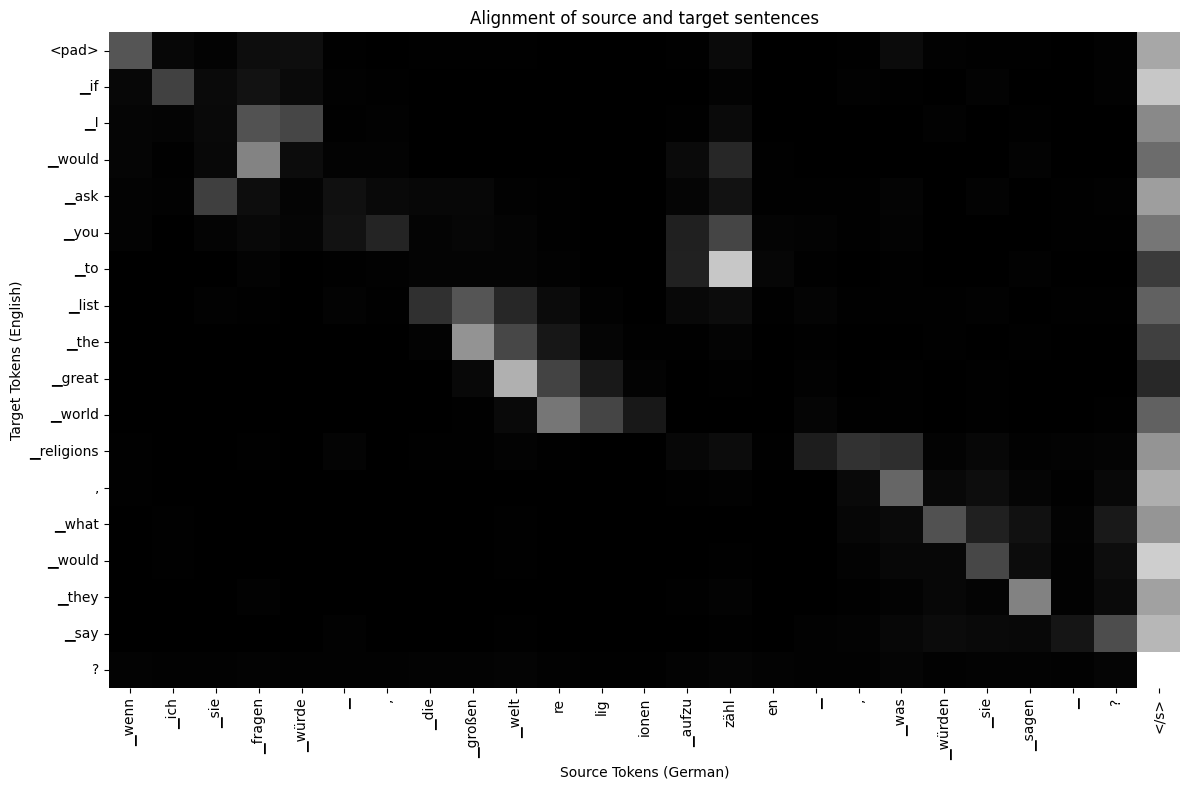

Pruned 30%: if I would ask you to list the great world religions, what would they say?


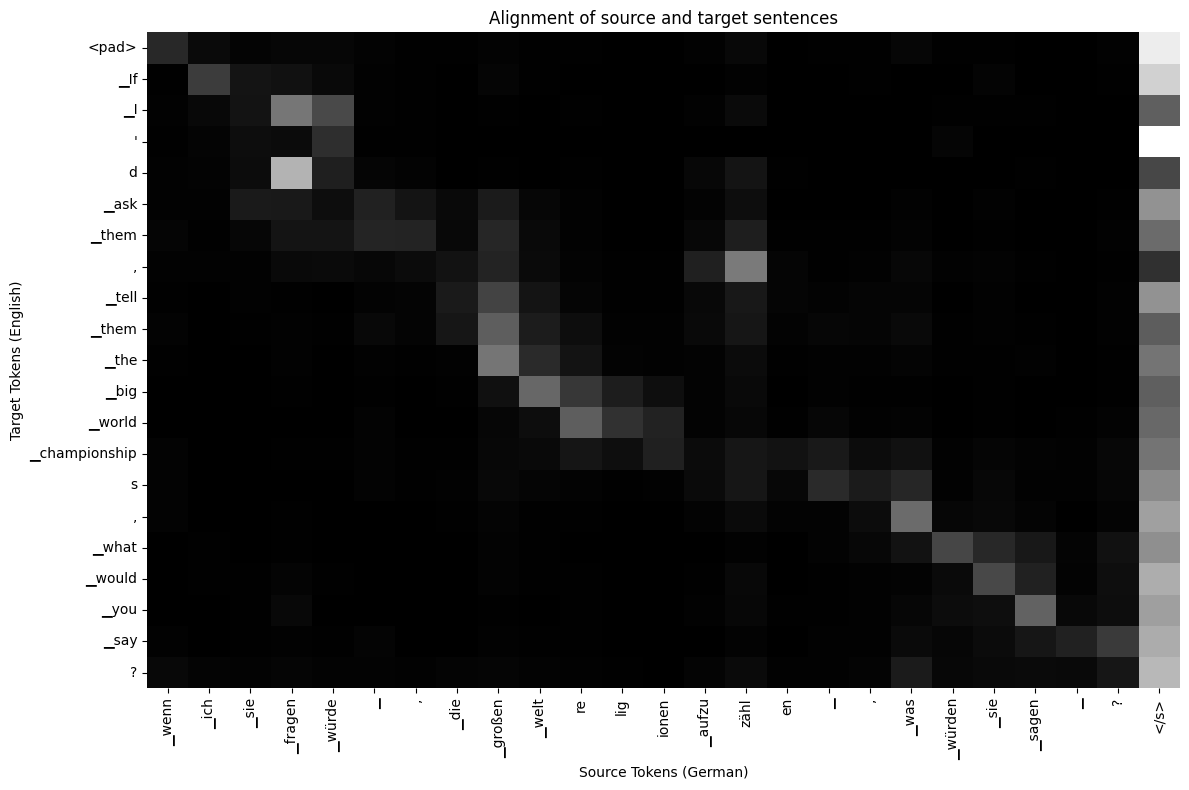

Pruned 50%: If I'd ask them, tell them the big world championships, what would you say?


In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model and tokenizer
model_name = "Helsinki-NLP/opus-mt-de-en"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def global_magnitude_prune(model, prune_percent):
    all_weights = []
    with torch.no_grad():
        for name, param in model.named_parameters():
            if 'weight' in name and 'LayerNorm' not in name and 'bias' not in name:
                weights = param.data.abs().cpu().numpy().ravel()
                all_weights.append(weights)
        
        if not all_weights:
            return model
        
        flat_weights = np.concatenate(all_weights)
        threshold = np.percentile(flat_weights, prune_percent)
        
        for name, param in model.named_parameters():
            if 'weight' in name and 'LayerNorm' not in name and 'bias' not in name:
                mask = param.data.abs() > torch.tensor(threshold, device=param.device)
                param.data.mul_(mask)
    
    return model



def translate_and_visualize(model, sentence):
    model.eval()
    model.to(device)

    # Tokenize source sentence
    inputs = tokenizer(sentence, return_tensors="pt").to(device)

    # Step 1: Generate translation (to get decoder_input_ids)
    with torch.no_grad():
        generated = model.generate(
            **inputs,
            return_dict_in_generate=True,
            output_scores=False
        )
    translation_ids = generated.sequences[0]
    translation = tokenizer.decode(translation_ids, skip_special_tokens=True)

    # Step 2: Manually run decoder to extract cross-attention
    with torch.no_grad():
        encoder_outputs = model.get_encoder()(**inputs)

        # Create decoder_input_ids by shifting right
        decoder_input_ids = translation_ids.unsqueeze(0)
        decoder_input_ids = decoder_input_ids[:, :-1]  # remove </s> token
        # If empty, add <pad> as placeholder
        if decoder_input_ids.shape[1] == 0:
            decoder_input_ids = torch.tensor([[tokenizer.pad_token_id]], device=device)

        output = model(
            encoder_outputs=encoder_outputs,
            decoder_input_ids=decoder_input_ids,
            output_attentions=True,
            return_dict=True
        )

    # Step 3: Extract cross-attention weights
    cross_attn = output.cross_attentions[-1][0].mean(dim=0).cpu().numpy()

    # Decode token lists
    source_tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    target_tokens = tokenizer.convert_ids_to_tokens(decoder_input_ids[0])

    # Plot heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(cross_attn[:len(target_tokens), :len(source_tokens)],
                xticklabels=source_tokens,
                yticklabels=target_tokens,
                cmap="gray", cbar=False)

    plt.xlabel("Source Tokens (German)")
    plt.ylabel("Target Tokens (English)")
    plt.title("Alignment of source and target sentences")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return translation

def class_distribution_prune(model, prune_percent):
    """Class-distribution pruning using σ_c per layer and λ determined to prune x% globally."""
    with torch.no_grad():
        all_std_weight_products = []

        # Step 1: Collect all σ_c for layers and store weight values
        layer_data = []
        for name, param in model.named_parameters():
            if 'weight' in name and 'LayerNorm' not in name and 'bias' not in name:
                weights = param.data.abs().cpu().numpy()
                std_c = np.std(weights)
                if std_c == 0:
                    continue
                scaled_weights = weights / std_c
                all_std_weight_products.extend(scaled_weights.ravel())
                layer_data.append((param, std_c))

        if not all_std_weight_products:
            return model

        # Step 2: Determine λ using global percentile
        lambda_thresh = np.percentile(all_std_weight_products, prune_percent)

        # Step 3: Prune based on class-dependent thresholds
        # initial_sparsity = calculate_sparsity(model)
        for param, std_c in layer_data:
            threshold = lambda_thresh * std_c
            mask = param.data.abs() > torch.tensor(threshold, device=param.device)
            param.data.mul_(mask)

        # final_sparsity = calculate_sparsity(model)
        # print(f"[Class-Distribution] Requested: {prune_percent}% | Achieved: {final_sparsity:.2f}% | "
        #       f"New zeros: {final_sparsity - initial_sparsity:.2f}%")
    
    return model

# Sentence to translate
german_sentence = "wenn ich sie fragen würde , die großen weltreligionen aufzuzählen , was würden sie sagen ?"

# Prune percentages
prune_levels = [30, 50]

# Translate and visualize for each prune level
for pct in prune_levels:
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)
    pruned_model = class_distribution_prune(model, pct)
    translation = translate_and_visualize(pruned_model, german_sentence)
    print(f"Pruned {pct}%: {translation}")